# Week 8 Phase 1 — final sample-efficiency quantification

This notebook turns the frozen Week 7 real-data active-learning experiment into concrete simulator-budget statements. It reads authoritative saved rows only. It does **not** run a simulator, fit a new acquisition family, change a split, relabel a case, or retune the Binary GPC.

The primary result is empirical held-out accuracy on B1-q20/q30 boundary-like subsets. Saved GPC probabilities support a separate confidence/calibration diagnostic; neither quantity is called certainty about the continuous physical boundary.

## 1. Week 8 question

We ask how much held-out boundary-region performance is obtained for each total simulator-query budget and how many queries Binary saves relative to Random.

**What does this mean in plain English?** The task is measurement and consolidation, not another method-development round.

In [1]:
question = "How many total queries are needed for a declared empirical boundary-accuracy target?"
print(question)
print("Mode: offline / retrospective; no new simulator runs")

How many total queries are needed for a declared empirical boundary-accuracy target?
Mode: offline / retrospective; no new simulator runs


## 2. Exact Phase 7 provenance

The Week 8 worktree must start at the exact published Phase 7 commit and preserve its validation state.

**What does this mean in plain English?** Every result below is tied to one exact published parent, so later prose cannot silently drift to another experiment.

In [2]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
from IPython.display import Image, display

ROOT = Path.cwd()
OUT1 = ROOT / "outputs/week8_01_final_sample_efficiency"
OUT2 = ROOT / "outputs/week8_02_thesis_consolidation"
P7 = ROOT / "outputs/week7_07_final_boundary_hybrid_benchmark"
preflight = json.loads((OUT1 / "phase8_01_preflight.json").read_text(encoding="utf-8"))
source_audit = json.loads((OUT1 / "phase7_source_audit.json").read_text(encoding="utf-8"))
display(pd.Series({
    "Week 8 branch": preflight["week8_branch"],
    "exact Phase 7 parent": preflight["exact_phase7_parent"],
    "remote verified": preflight["remote_phase7_verified"],
    "Phase 7 validation": f"{source_audit['phase7_validation_pass']}/{source_audit['phase7_validation_total']} PASS",
    "expensive benchmark rerun": preflight["expensive_experiment_rerun"],
}))

Week 8 branch                codex/week8-final-sample-efficiency-thesis-con...
exact Phase 7 parent                  167aad945b20822de712e891e901bd3ec6d5ffc6
remote verified                                                           True
Phase 7 validation                                                  34/34 PASS
expensive benchmark rerun                                                False
dtype: object

## 3. Frozen primary method

The final primary arm is Binary GPC plus `binary_uncertainty_repulsion`. Random is the exact shared baseline and Max-Depth straddle is the secondary comparator.

**What does this mean in plain English?** The winner is already frozen; Week 8 quantifies its sample efficiency without tuning it again.

In [3]:
methods = pd.DataFrame([
    ["Binary", "binary_uncertainty_repulsion", "primary"],
    ["Random", "shared_random_binary_head", "baseline"],
    ["Max-Depth", "max_depth_straddle", "secondary continuous comparator"],
], columns=["display", "saved method id", "Week 8 role"])
display(methods)
print("Inputs: P, VX, LS, ST; ST = substrate temperature")

,display,saved method id,Week 8 role
0,Binary,binary_uncertainty_repulsion,primary
1,Random,shared_random_binary_head,baseline
2,Max-Depth,max_depth_straddle,secondary continuous comparator


Inputs: P, VX, LS, ST; ST = substrate temperature


## 4. Load the authoritative 20 matched runs

The row-level learning curves retain all repeated folds and all integer budgets. We filter only the three declared Week 8 methods.

**What does this mean in plain English?** All comparisons use the same 20 outer runs; a favorable run is never selected by hand.

In [4]:
raw = pd.read_csv(P7 / "phase7_learning_curve_summary.csv", low_memory=False)
method_ids = methods["saved method id"].tolist()
learning = raw[raw["method"].isin(method_ids)].copy()
display(learning.groupby("method").agg(runs=("run_id", "nunique"), min_budget=("budget", "min"), max_budget=("budget", "max")))
assert learning["run_id"].nunique() == 20

,runs,min_budget,max_budget
method,,,
binary_uncertainty_repulsion,20,12,80
max_depth_straddle,20,12,80
shared_random_binary_head,20,12,80


## 5. Reconcile the budget axis

Nineteen runs start at 12 queries and one effective warm start is 16. Therefore the complete matched mean-curve grid begins at budget 16.

**What does this mean in plain English?** Run-level first crossings can begin at each run's real warm start, while aggregate curves and AULCs use the fair common 16–80 grid.

In [5]:
coverage = learning.groupby(["method", "budget"])["run_id"].nunique().unstack(0)
display(coverage.loc[12:20])
assert (coverage.loc[16:80] == 20).all().all()
common_start, final_budget = 16, 80

method,binary_uncertainty_repulsion,max_depth_straddle,shared_random_binary_head
budget,,,
12,19,19,19
13,19,19,19
14,19,19,19
15,19,19,19
16,20,20,20
17,20,20,20
18,20,20,20
19,20,20,20
20,20,20,20


## 6. What q20 and q30 mean

B1 ranks simulations by standardized distance to the nearest simulation with the opposite manual label. q20 and q30 select the most boundary-like 20% and 30% for evaluation only.

**What does this mean in plain English?** q20/q30 are declared subsets of sampled held-out points, not confidence bands around a continuous physical contour.

In [6]:
predictions = pd.read_csv(P7 / "phase7_all_method_prediction_checkpoints.csv", low_memory=False)
check = predictions[(predictions["method"] == "binary_uncertainty_repulsion") & (predictions["budget"] == 40)]
display(pd.Series({
    "pooled B1-q20 held-out prediction rows": int(check["test_B1_q20"].sum()),
    "pooled B1-q30 held-out prediction rows": int(check["test_B1_q30"].sum()),
    "outer runs": check["run_id"].nunique(),
}))

pooled B1-q20 held-out prediction rows    340
pooled B1-q30 held-out prediction rows    500
outer runs                                 20
dtype: int64

## 7. Convert boundary error to accuracy

For every run and budget, empirical boundary accuracy is defined exactly as one minus the saved boundary error.

**What does this mean in plain English?** The reported percentages are a transparent relabelling of error, not a newly fitted or smoothed statistic.

In [7]:
learning["recomputed_B1_q20_accuracy"] = 1 - learning["B1_q20_error"]
saved_curve = pd.read_csv(OUT1 / "boundary_accuracy_run_level.csv")
merged = saved_curve[(saved_curve["boundary_definition"] == "B1") & (saved_curve["quantile"] == 20)].merge(
    learning[["run_id", "method", "budget", "recomputed_B1_q20_accuracy"]],
    on=["run_id", "method", "budget"], validate="one_to_one"
)
max_difference = (merged["boundary_accuracy"] - merged["recomputed_B1_q20_accuracy"]).abs().max()
print("maximum absolute identity difference:", max_difference)
assert max_difference < 1e-12

maximum absolute identity difference: 4.705125178361413e-13


## 8. Budget snapshots

The headline budgets show q20/q30 accuracy, global balanced accuracy, and discovery counts side by side.

**What does this mean in plain English?** At budget 40, Binary is 81.2% on B1-q20 versus Random 76.8%; the difference is 4.4 percentage points.

In [8]:
snapshots = pd.read_csv(OUT1 / "budget_snapshot_b1.csv")
view = snapshots[snapshots["budget"].isin([20, 30, 40, 50, 60, 70, 80])][[
    "budget", "method_label", "mean_q20_accuracy", "mean_q30_accuracy",
    "mean_balanced_accuracy", "mean_keyhole_discovered"
]]
display(view.style.format({
    "mean_q20_accuracy": "{:.1%}", "mean_q30_accuracy": "{:.1%}",
    "mean_balanced_accuracy": "{:.1%}", "mean_keyhole_discovered": "{:.2f}"
}))

,budget,method_label,mean_q20_accuracy,mean_q30_accuracy,mean_balanced_accuracy,mean_keyhole_discovered
3,20,Binary,77.6%,83.2%,89.2%,7.40
4,20,Max-Depth,75.3%,80.8%,92.7%,5.70
5,20,Random,72.9%,79.4%,78.9%,3.55
6,30,Binary,79.7%,85.4%,91.0%,12.20
7,30,Max-Depth,79.1%,84.6%,94.3%,8.30
8,30,Random,77.4%,83.0%,86.4%,5.45
9,40,Binary,81.2%,86.2%,91.4%,16.80
10,40,Max-Depth,77.9%,84.0%,93.1%,10.55
11,40,Random,76.8%,83.2%,89.3%,7.45
12,50,Binary,82.9%,88.0%,92.4%,20.90


## 9. B1-q20 learning curve

The mean curve and descriptive t intervals summarize the 20 matched run trajectories without smoothing.

**What does this mean in plain English?** Binary remains above Random over most of the common budget range; Max-Depth exposes the boundary/global trade-off.

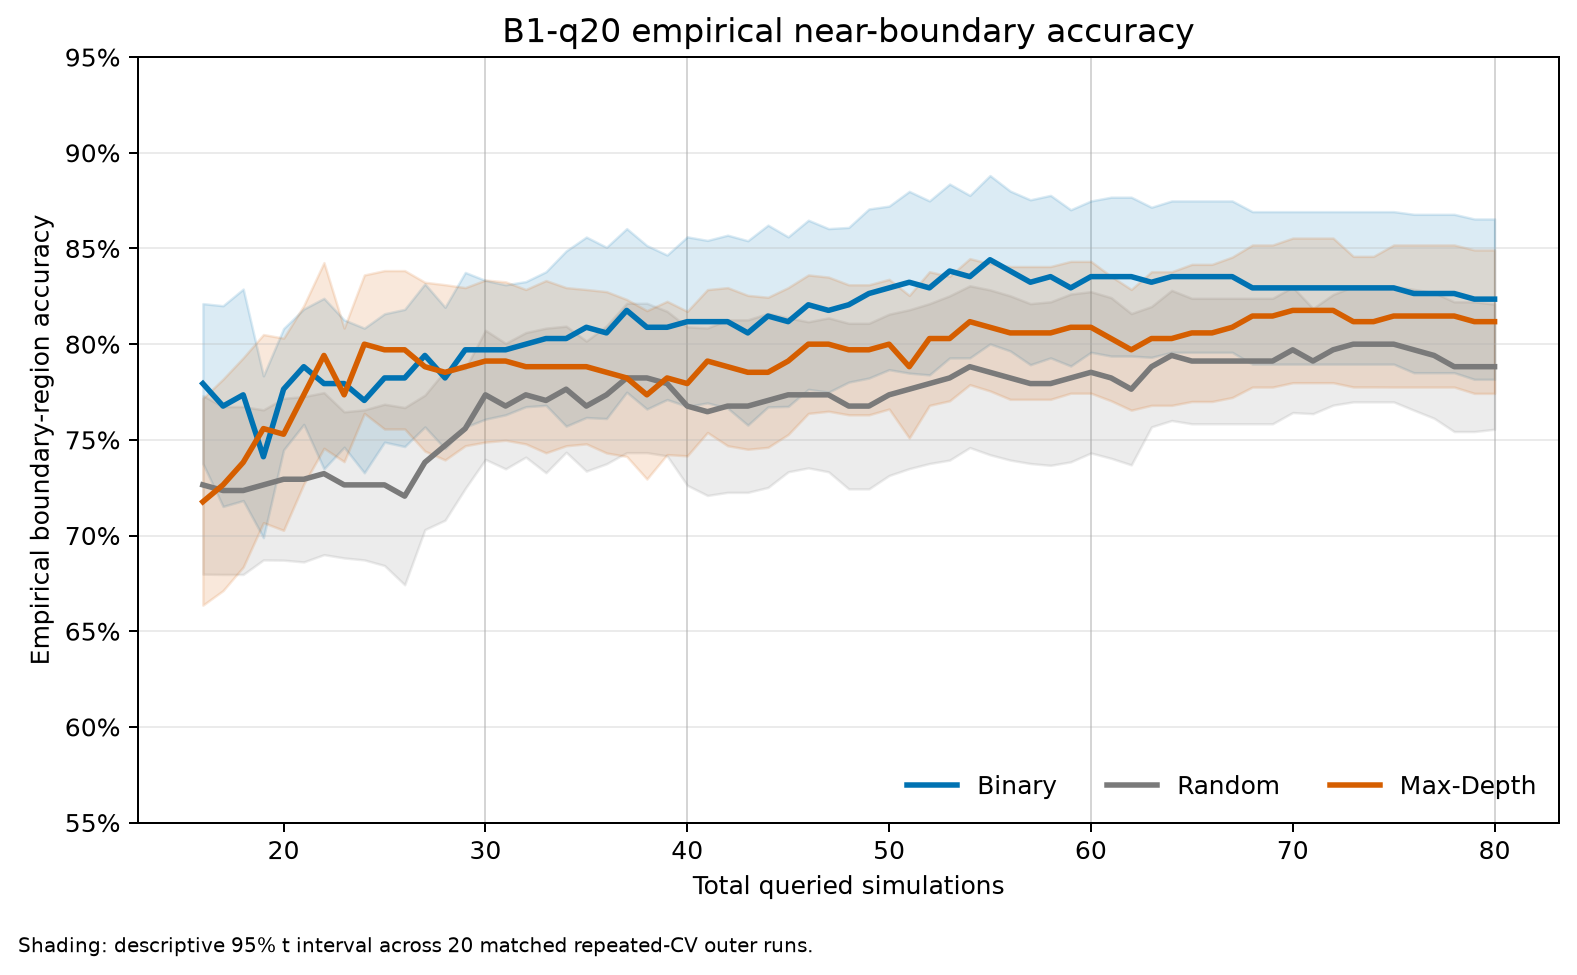

In [9]:
display(Image(filename=str(OUT1 / "figures/01_b1_q20_accuracy_vs_budget.png")))

## 10. B1-q30 learning curve

q30 broadens the evaluation region and checks that the conclusion is not unique to the narrow q20 subset.

**What does this mean in plain English?** At budget 40, Binary reaches 86.2% B1-q30 accuracy versus 83.2% for Random.

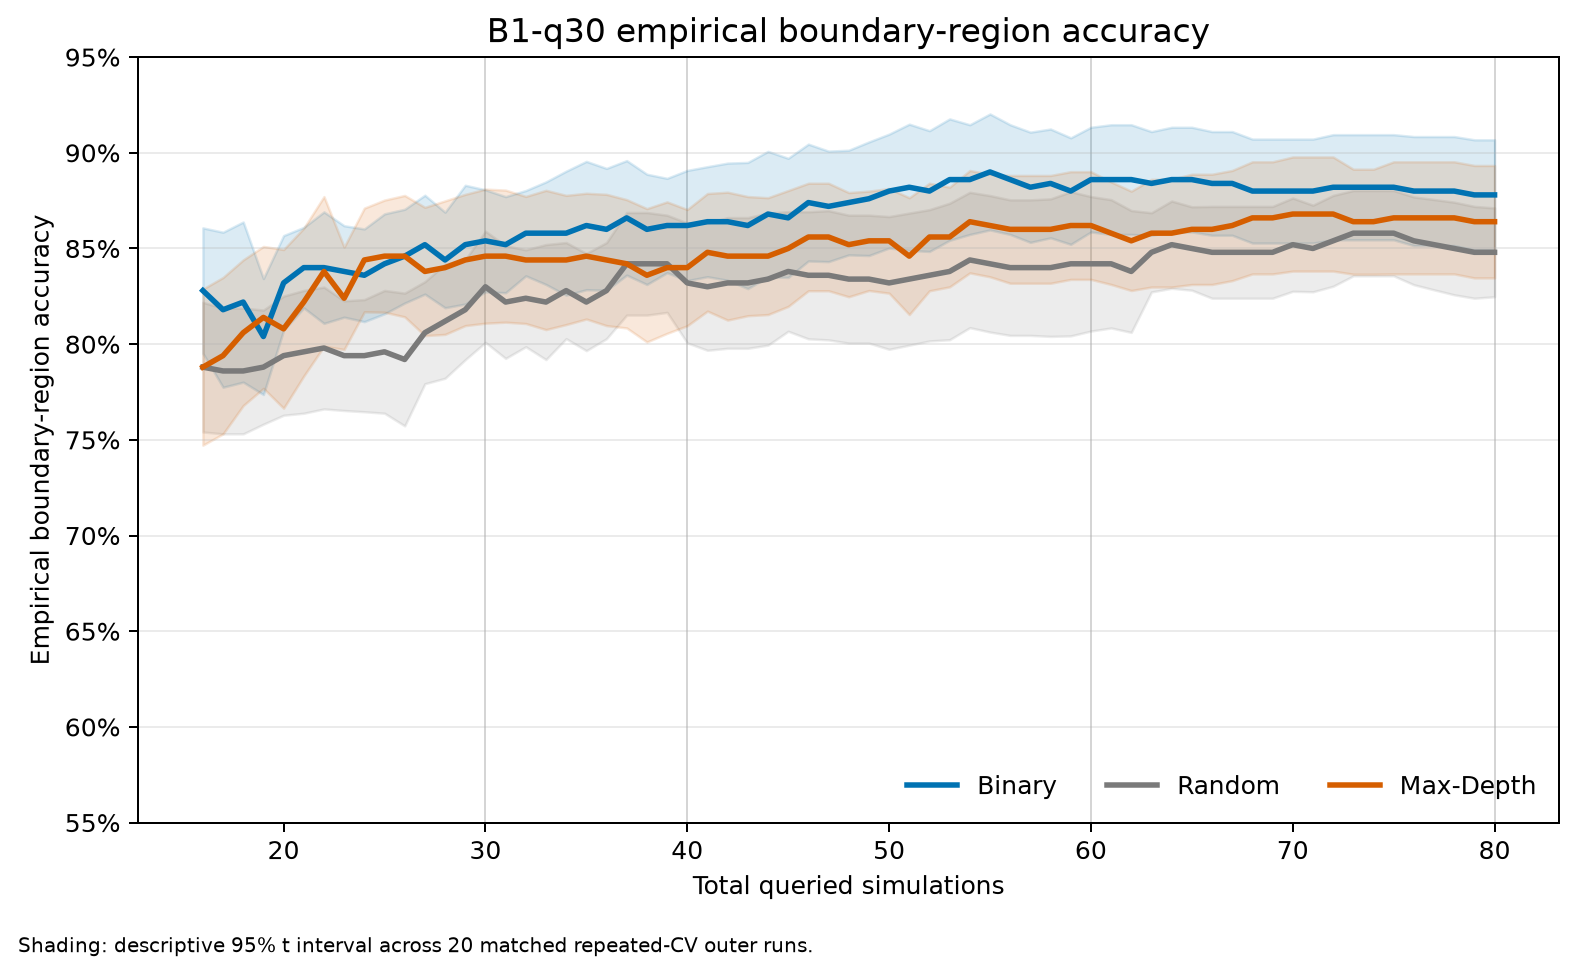

In [10]:
display(Image(filename=str(OUT1 / "figures/02_b1_q30_accuracy_vs_budget.png")))

## 11. Queries to 70% accuracy

First crossing is the first observed integer budget at which a run meets the target. Unsuccessful runs stay explicit rather than being assigned budget 81.

**What does this mean in plain English?** The 70% target is easy for this discrete held-out subset and is often met at the warm start.

In [11]:
targets = pd.read_csv(OUT1 / "queries_to_accuracy_target.csv")
target_70 = targets[(targets["boundary_definition"] == "B1") & (targets["target_accuracy_percent"] == 70)][[
    "quantile", "method_label", "successful_runs", "total_runs",
    "median_queries_successful_runs", "mean_queries_successful_runs", "not_reached_by_80"
]]
display(target_70)

,quantile,method_label,successful_runs,total_runs,median_queries_successful_runs,mean_queries_successful_runs,not_reached_by_80
0,20,Binary,20,20,12.0,13.25,0
1,20,Max-Depth,20,20,13.0,14.65,0
2,20,Random,20,20,12.0,15.65,0
15,30,Binary,20,20,12.0,12.50,0
16,30,Max-Depth,20,20,12.0,13.00,0
17,30,Random,20,20,12.0,13.25,0


## 12. Queries to 75% accuracy

First crossing is the first observed integer budget at which a run meets the target. Unsuccessful runs stay explicit rather than being assigned budget 81.

**What does this mean in plain English?** At 75%, reach counts begin to expose run-to-run difficulty even when conditional medians remain early.

In [12]:
targets = pd.read_csv(OUT1 / "queries_to_accuracy_target.csv")
target_75 = targets[(targets["boundary_definition"] == "B1") & (targets["target_accuracy_percent"] == 75)][[
    "quantile", "method_label", "successful_runs", "total_runs",
    "median_queries_successful_runs", "mean_queries_successful_runs", "not_reached_by_80"
]]
display(target_75)

,quantile,method_label,successful_runs,total_runs,median_queries_successful_runs,mean_queries_successful_runs,not_reached_by_80
3,20,Binary,19,20,13.0,14.894737,1
4,20,Max-Depth,20,20,15.0,20.200000,0
5,20,Random,19,20,17.0,24.000000,1
18,30,Binary,20,20,12.0,12.800000,0
19,30,Max-Depth,20,20,13.0,16.150000,0
20,30,Random,20,20,12.0,15.100000,0


## 13. Queries to 80% accuracy

First crossing is the first observed integer budget at which a run meets the target. Unsuccessful runs stay explicit rather than being assigned budget 81.

**What does this mean in plain English?** The 80% target is a useful operational reference: it separates Binary's reach reliability from Random.

In [13]:
targets = pd.read_csv(OUT1 / "queries_to_accuracy_target.csv")
target_80 = targets[(targets["boundary_definition"] == "B1") & (targets["target_accuracy_percent"] == 80)][[
    "quantile", "method_label", "successful_runs", "total_runs",
    "median_queries_successful_runs", "mean_queries_successful_runs", "not_reached_by_80"
]]
display(target_80)

,quantile,method_label,successful_runs,total_runs,median_queries_successful_runs,mean_queries_successful_runs,not_reached_by_80
6,20,Binary,18,20,16.0,17.111111,2
7,20,Max-Depth,15,20,15.0,16.600000,5
8,20,Random,14,20,30.0,34.071429,6
21,30,Binary,20,20,14.5,14.450000,0
22,30,Max-Depth,20,20,14.5,18.450000,0
23,30,Random,20,20,16.0,20.500000,0


## 14. Queries to 85% accuracy

First crossing is the first observed integer budget at which a run meets the target. Unsuccessful runs stay explicit rather than being assigned budget 81.

**What does this mean in plain English?** The 85% target is more demanding; success counts are as important as the conditional median.

In [14]:
targets = pd.read_csv(OUT1 / "queries_to_accuracy_target.csv")
target_85 = targets[(targets["boundary_definition"] == "B1") & (targets["target_accuracy_percent"] == 85)][[
    "quantile", "method_label", "successful_runs", "total_runs",
    "median_queries_successful_runs", "mean_queries_successful_runs", "not_reached_by_80"
]]
display(target_85)

,quantile,method_label,successful_runs,total_runs,median_queries_successful_runs,mean_queries_successful_runs,not_reached_by_80
9,20,Binary,15,20,21.0,21.600000,5
10,20,Max-Depth,12,20,18.5,21.583333,8
11,20,Random,8,20,29.0,35.875000,12
24,30,Binary,18,20,16.0,17.666667,2
25,30,Max-Depth,15,20,17.0,19.066667,5
26,30,Random,14,20,31.0,36.357143,6


## 15. Queries to 90% accuracy

First crossing is the first observed integer budget at which a run meets the target. Unsuccessful runs stay explicit rather than being assigned budget 81.

**What does this mean in plain English?** At 90%, many runs are censored by budget 80, so no universal query count is claimed.

In [15]:
targets = pd.read_csv(OUT1 / "queries_to_accuracy_target.csv")
target_90 = targets[(targets["boundary_definition"] == "B1") & (targets["target_accuracy_percent"] == 90)][[
    "quantile", "method_label", "successful_runs", "total_runs",
    "median_queries_successful_runs", "mean_queries_successful_runs", "not_reached_by_80"
]]
display(target_90)

,quantile,method_label,successful_runs,total_runs,median_queries_successful_runs,mean_queries_successful_runs,not_reached_by_80
12,20,Binary,8,20,27.5,29.125000,12
13,20,Max-Depth,5,20,22.0,21.800000,15
14,20,Random,3,20,28.0,28.000000,17
27,30,Binary,14,20,23.0,24.571429,6
28,30,Max-Depth,11,20,19.0,23.000000,9
29,30,Random,8,20,44.5,43.500000,12


## 16. Random-equivalent budget

For each selected Binary budget, we find the first crossing of Binary's mean B1-q20 accuracy on the observed Random mean curve, using linear interpolation only between adjacent saved budgets.

**What does this mean in plain English?** Binary at budget 30 is matched near Random budget 70; Binary at 40 is not matched by 80, so the latter remains a strict lower bound.

In [16]:
random_equivalent = pd.read_csv(OUT1 / "random_equivalent_budget.csv")
display(random_equivalent[[
    "binary_budget", "binary_mean_accuracy", "random_equivalent_budget_display",
    "query_saving_display", "efficiency_multiplier_display", "status"
]].style.format({"binary_mean_accuracy": "{:.1%}"}))

,binary_budget,binary_mean_accuracy,random_equivalent_budget_display,query_saving_display,efficiency_multiplier_display,status
0,20,77.6%,34.00,14.00,1.70x,matched_within_observed_curve
1,30,79.7%,70.00,40.00,2.33x,matched_within_observed_curve
2,40,81.2%,>80,>40,>2.00x,not_matched_by_80
3,50,82.9%,>80,>30,>1.60x,not_matched_by_80
4,60,83.5%,>80,>20,>1.33x,not_matched_by_80


## 17. Simulator-query savings

Savings equal Random-equivalent budget minus Binary budget. Values above the observed horizon are shown only as lower bounds.

**What does this mean in plain English?** The strongest exact result is about 40 saved calls for 79.7% mean B1-q20 accuracy; the budget-40 result is >40.

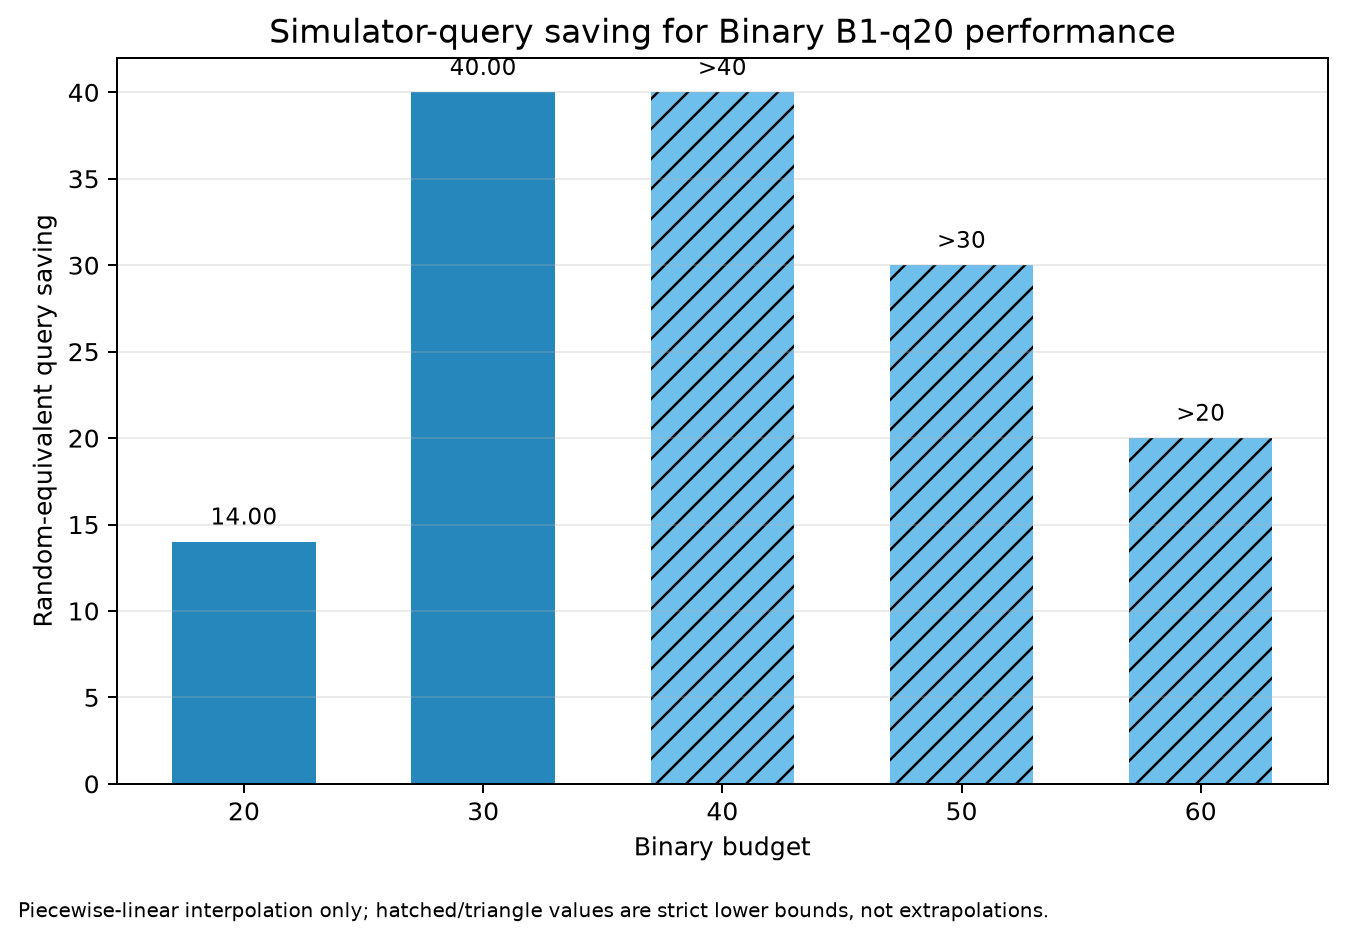

In [17]:
display(Image(filename=str(OUT1 / "figures/07_query_savings.png")))

## 18. Matched-run evidence and persistent crossings

Aggregate savings are supplemented by paired run outcomes. Persistence requires the target to hold at the crossing and the next two stored integer budgets.

**What does this mean in plain English?** Non-monotonic curves matter: first crossing is primary, while persistent crossing shows whether a threshold survives the next two observations.

In [18]:
matched = pd.read_csv(OUT1 / "matched_query_savings.csv")
persistent = pd.read_csv(OUT1 / "persistent_queries_to_accuracy_target.csv")
display(matched)
display(persistent[(persistent["boundary_definition"] == "B1") & (persistent["quantile"] == 20) & (persistent["target_accuracy_percent"] == 80)][[
    "method_label", "successful_runs", "median_queries_successful_runs", "not_reached_by_80"
]])

,boundary_definition,quantile,target_accuracy,target_accuracy_percent,matched_run_count,count_binary_earlier,count_tie,count_random_earlier,count_binary_reached_random_not_reached,count_random_reached_binary_not_reached,count_neither_reached,jointly_reached_count,paired_median_random_minus_binary_queries,paired_mean_random_minus_binary_queries,paired_q25_random_minus_binary_queries,paired_q75_random_minus_binary_queries,not_reached_not_imputed
0,B1,20,0.75,75,20,9,8,2,0,0,1,19,0.0,9.105263,0.0,13.50,True
1,B1,20,0.80,80,20,10,3,1,4,0,2,14,14.0,17.428571,0.5,21.75,True
2,B1,20,0.85,85,20,6,2,0,7,0,5,8,11.5,16.500000,6.0,27.25,True
3,B1,30,0.75,75,20,5,15,0,0,0,0,20,0.0,2.300000,0.0,0.25,True
4,B1,30,0.80,80,20,9,9,2,0,0,0,20,0.0,6.050000,0.0,9.00,True
5,B1,30,0.85,85,20,12,2,0,4,0,2,14,16.5,19.142857,8.0,21.75,True


,method_label,successful_runs,median_queries_successful_runs,not_reached_by_80
6,Binary,18,20.5,2
7,Max-Depth,14,17.5,6
8,Random,14,30.0,6


## 19. Keyhole discovery efficiency

Discovery counts and enrichment use the actual candidate-pool prevalence for each run.

**What does this mean in plain English?** Binary finds substantially more positive cases than Random, but this secondary behavior is not substituted for held-out boundary accuracy.

,budget,method_label,mean_keyhole_discovered,mean_keyhole_enrichment
3,20,Binary,7.40,2.05x
4,20,Max-Depth,5.70,1.58x
5,20,Random,3.55,0.99x
6,30,Binary,12.20,2.26x
7,30,Max-Depth,8.30,1.54x
8,30,Random,5.45,1.01x
9,40,Binary,16.80,2.33x
10,40,Max-Depth,10.55,1.46x
11,40,Random,7.45,1.03x
15,60,Binary,24.65,2.28x


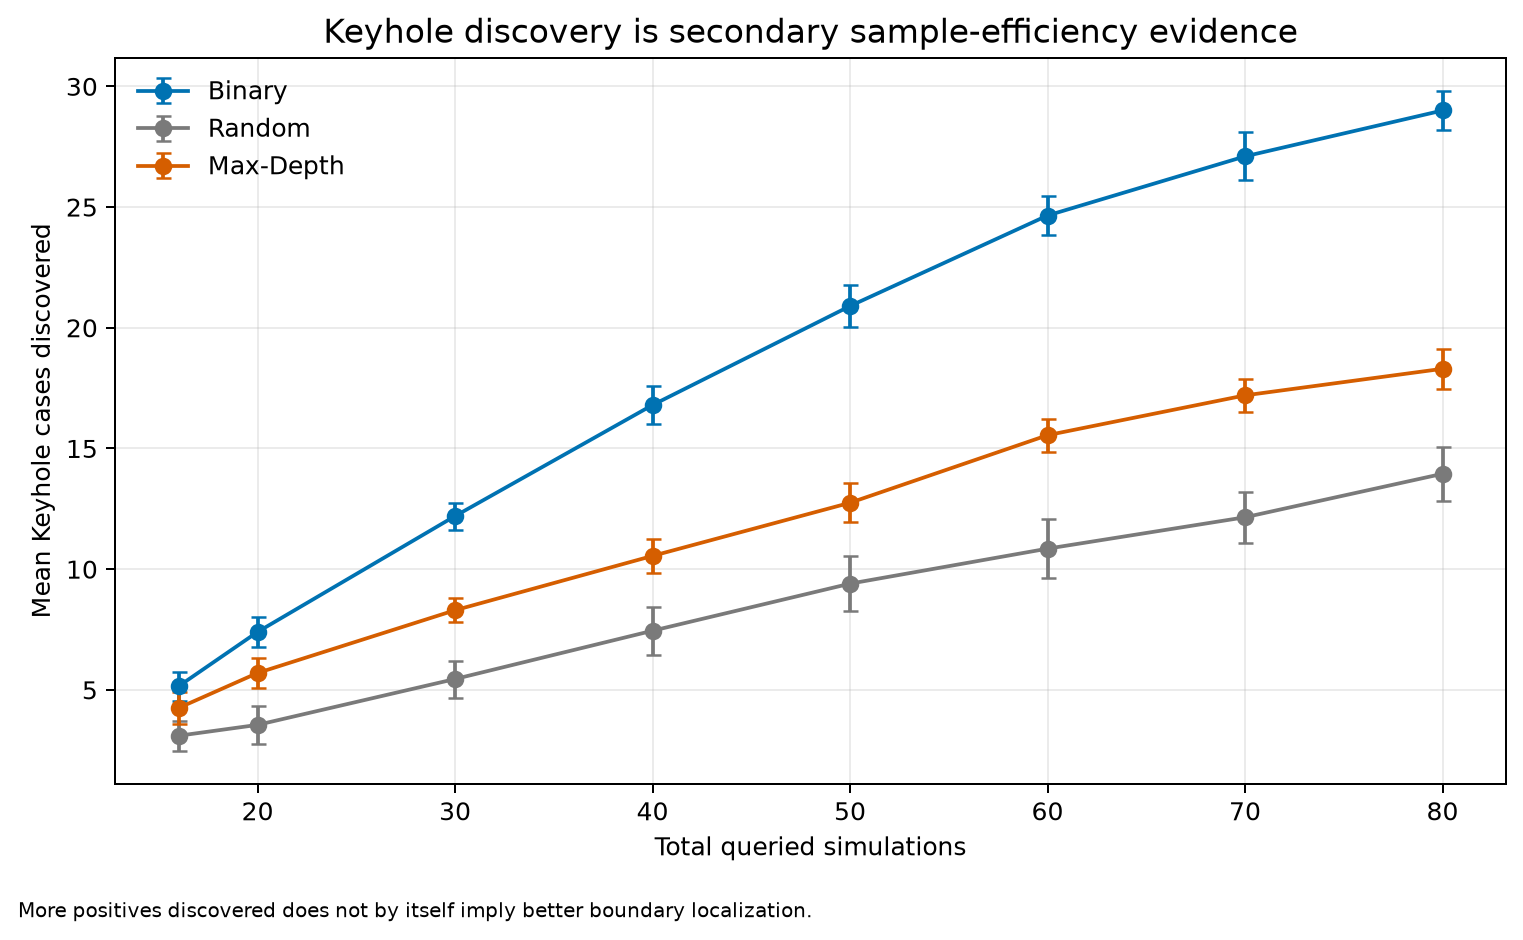

In [19]:
discovery = pd.read_csv(OUT1 / "keyhole_discovery_by_budget.csv")
display(discovery[discovery["budget"].isin([20, 30, 40, 60, 80])][[
    "budget", "method_label", "mean_keyhole_discovered", "mean_keyhole_enrichment"
]].style.format({"mean_keyhole_discovered": "{:.2f}", "mean_keyhole_enrichment": "{:.2f}x"}))
display(Image(filename=str(OUT1 / "figures/08_keyhole_discovery.png")))

## 20. Saved predictive confidence and calibration

Because Phase 7 stored held-out GPC probabilities, we can report confidence bands, correctness within those bands, Brier score, and fixed-bin reliability diagnostics.

**What does this mean in plain English?** At budget 40, 48.2% of B1-q20 predictions carry at least 80% model confidence and 93.3% of that band is correct; this is model confidence, not physical-boundary certainty.

,budget,subset,pooled_mean_confidence,fraction_confidence_ge_080,accuracy_confidence_ge_080,fraction_confidence_ge_090,accuracy_confidence_ge_090,pooled_brier_score,confidence_ece_10_equal_width_bins
0,20,B1_q20,69.8%,24.4%,92.8%,3.2%,100.0%,0.164,0.078
1,20,B1_q30,71.6%,29.4%,95.9%,4.4%,100.0%,0.138,0.116
14,40,B1_q20,77.4%,48.2%,93.3%,22.1%,98.7%,0.133,0.056
15,40,B1_q30,79.5%,55.4%,96.0%,27.2%,99.3%,0.104,0.077
28,80,B1_q20,81.9%,60.0%,94.1%,43.8%,94.6%,0.119,0.049
29,80,B1_q30,84.8%,69.0%,96.5%,51.8%,96.9%,0.087,0.047


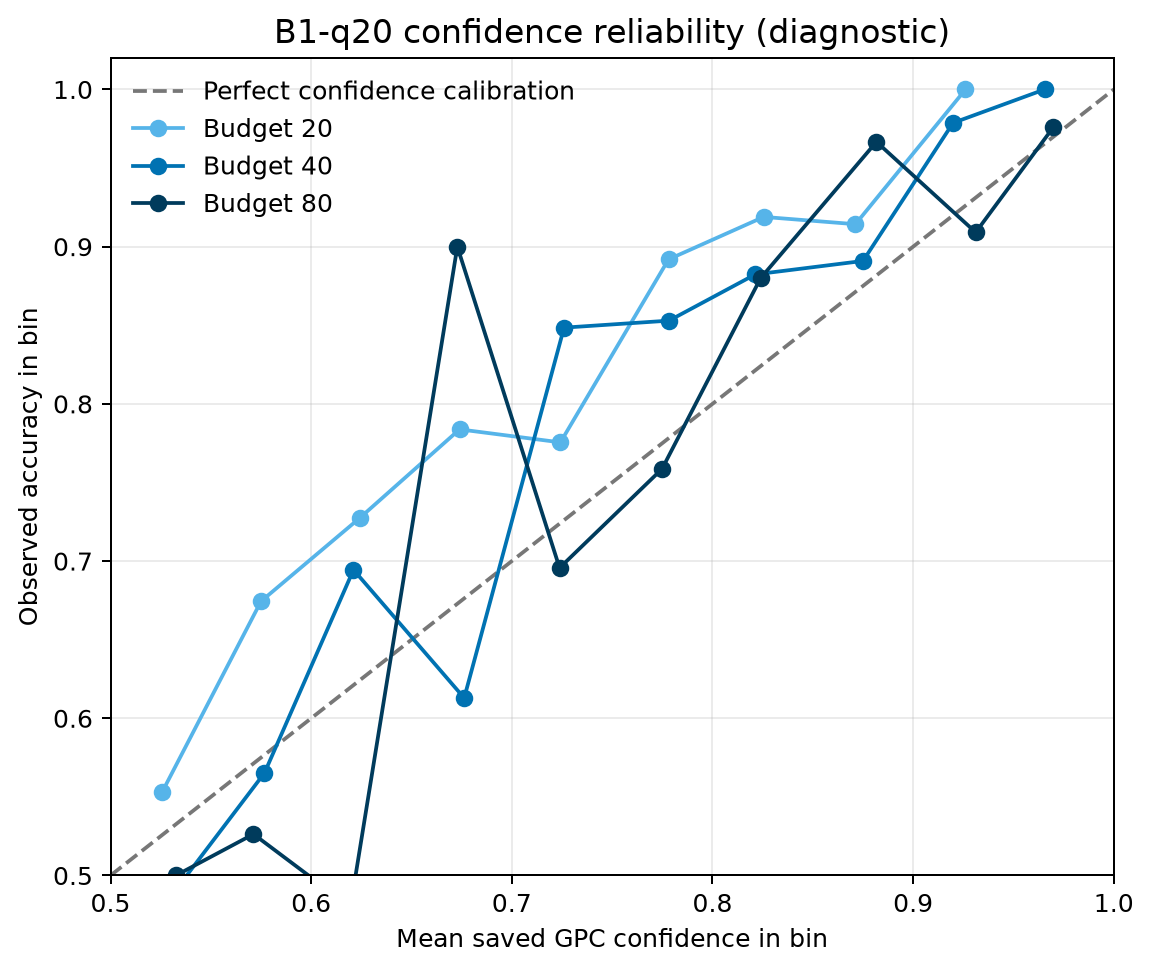

In [20]:
confidence = pd.read_csv(OUT1 / "predictive_confidence_summary.csv")
display(confidence[(confidence["boundary_definition"] == "B1") & (confidence["budget"].isin([20, 40, 80]))][[
    "budget", "subset", "pooled_mean_confidence", "fraction_confidence_ge_080",
    "accuracy_confidence_ge_080", "fraction_confidence_ge_090",
    "accuracy_confidence_ge_090", "pooled_brier_score",
    "confidence_ece_10_equal_width_bins"
]].style.format({
    "pooled_mean_confidence": "{:.1%}", "fraction_confidence_ge_080": "{:.1%}",
    "accuracy_confidence_ge_080": "{:.1%}", "fraction_confidence_ge_090": "{:.1%}",
    "accuracy_confidence_ge_090": "{:.1%}", "pooled_brier_score": "{:.3f}",
    "confidence_ece_10_equal_width_bins": "{:.3f}"
}))
display(Image(filename=str(OUT1 / "figures/10_predictive_confidence_reliability.png")))

## 21. B2/B3 robustness

The same saved predictions are re-evaluated under local label disagreement (B2) and relative same/opposite class distance (B3). These metrics never enter acquisition.

**What does this mean in plain English?** Binary's q20 error AULC remains lower than Random under B1, B2, and B3, while Max-Depth remains strongest on global balanced accuracy.

In [21]:
scorecard = pd.read_csv(OUT2 / "final_real_data_scorecard.csv")
display(scorecard[[
    "method_label", "mean_B1_q20_error_aulc", "mean_B2_q20_error_aulc",
    "mean_B3_q20_error_aulc", "mean_balanced_accuracy_aulc"
]].style.format({column: "{:.4f}" for column in [
    "mean_B1_q20_error_aulc", "mean_B2_q20_error_aulc",
    "mean_B3_q20_error_aulc", "mean_balanced_accuracy_aulc"
]}))

,method_label,mean_B1_q20_error_aulc,mean_B2_q20_error_aulc,mean_B3_q20_error_aulc,mean_balanced_accuracy_aulc
0,Binary,0.1862,0.1924,0.1774,0.9171
1,Random,0.2289,0.2472,0.2266,0.8735
2,Max-Depth,0.2053,0.2018,0.2219,0.9432


## 22. Machine-traceable headline results

Every prose headline stores its source artifact and row filter so the thesis wording can be audited.

**What does this mean in plain English?** The strongest statements are attached to rows, not copied from visual estimates.

In [22]:
headlines = pd.read_csv(OUT1 / "headline_results.csv")
display(headlines[["claim_id", "statement", "source_artifact", "source_filter_or_metric"]])

,claim_id,statement,source_artifact,source_filter_or_metric
0,H01,"At 40 simulator queries, Binary reaches 81.2% ...",outputs/week8_01_final_sample_efficiency/budge...,"budget=40; methods=Binary,Random; mean_q20_acc..."
1,H02,"At 40 queries, Binary reaches 86.2% mean B1-q3...",outputs/week8_01_final_sample_efficiency/budge...,"budget=40; methods=Binary,Random; mean_q30_acc..."
2,H03,"For B1-q20 accuracy >=80%, Binary succeeds in ...",outputs/week8_01_final_sample_efficiency/queri...,"B1; q20; target=0.80; methods=Binary,Random"
3,H04,Binary's mean 79.7% B1-q20 accuracy at budget ...,outputs/week8_01_final_sample_efficiency/rando...,binary_budget=30
4,H05,Binary's mean 81.2% B1-q20 accuracy at budget ...,outputs/week8_01_final_sample_efficiency/rando...,binary_budget=40; status=not_matched_by_80
5,H06,"At budget 30, Binary has discovered 12.20 Keyh...",outputs/week8_01_final_sample_efficiency/keyho...,"budget=30; methods=Binary,Random"
6,H07,"At budget 40, 48.2% of held-out B1-q20 predict...",outputs/week8_01_final_sample_efficiency/predi...,budget=40; subset=B1_q20
7,H08,"Binary's B1-q20 accuracy AULC is 0.8138, compa...",outputs/week8_02_thesis_consolidation/final_re...,"methods=Binary,Random; mean_B1_q20_accuracy_aulc"
8,H09,The Binary advantage over Random is robust in ...,outputs/week8_02_thesis_consolidation/final_re...,"methods=Binary,Random; B2/B3 q20 error AULC"
9,H10,All sample-efficiency results are offline/retr...,outputs/week8_01_final_sample_efficiency/phase...,offline_retrospective_benchmark=true; prospect...


## 23. Scientific caveats

The evaluation is repeated cross-validation over saved simulations. GPC probabilities are saved but not post-hoc calibrated. B1/B2/B3 are empirical diagnostics.

**What does this mean in plain English?** The retrospective benchmark is valid, but its evidence boundary must remain visible in every thesis claim.

In [23]:
caveats = pd.Series({
    "prospective simulator deployment": False,
    "independent physical campaigns": False,
    "universal threshold claim": False,
    "causal claim": False,
    "continuous-boundary certainty claim": False,
    "offline held-out active-learning benchmark": True,
})
display(caveats)

prospective simulator deployment              False
independent physical campaigns                False
universal threshold claim                     False
causal claim                                  False
continuous-boundary certainty claim           False
offline held-out active-learning benchmark     True
dtype: bool

## 24. Phase 1 conclusion

We now have budget snapshots, target crossings, matched censoring-aware evidence, Random-equivalent savings, discovery enrichment, and model-confidence diagnostics.

**What does this mean in plain English?** Week 8 has converted 'sample-efficient' into concrete, defensible query counts without reopening method selection.

In [24]:
print(f"Budget 40 B1-q20: Binary {snapshots[(snapshots.budget==40)&(snapshots.method_label=='Binary')].mean_q20_accuracy.iloc[0]:.1%}; Random {snapshots[(snapshots.budget==40)&(snapshots.method_label=='Random')].mean_q20_accuracy.iloc[0]:.1%}")
print("Strongest exact saving: Binary budget 30 vs Random-equivalent budget 70 = 40 calls")
print("Primary method remains Binary GPC + uncertainty-repulsion")
print("No new simulator run was performed")

Budget 40 B1-q20: Binary 81.2%; Random 76.8%
Strongest exact saving: Binary budget 30 vs Random-equivalent budget 70 = 40 calls
Primary method remains Binary GPC + uncertainty-repulsion
No new simulator run was performed
